# ClosetAI · Predire il rischio di “capo fantasma”
## Classificazione logistica interpretabile

**Stato nel prodotto:** esperimento di ricerca, **non collegato alla
UI**. L'app rileva oggi i capi fantasma con una regola auditabile:
zero utilizzi e possesso da almeno una soglia di giorni.

Questo notebook esplora una domanda futura: usando soltanto dati
disponibili quando cataloghiamo un acquisto, possiamo stimare il
rischio che resti inutilizzato nei 90 giorni successivi?

In [1]:
# Trova la radice del repository anche se Jupyter parte da una sottocartella.
from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "backend" / "pyproject.toml").is_file() and (candidate / "ml").is_dir():
            return candidate
    raise FileNotFoundError("Radice di ClosetAI non trovata")

ROOT = find_project_root()
SEED = 42
print(f"Repository: {ROOT}")

Repository: C:\devel\closet-ai


In [2]:
# Dataset sintetico deterministico usato SOLO per l'esperimento didattico.
# In produzione queste righe dovrebbero arrivare dal wear log consensuale.
import numpy as np
import pandas as pd

CATEGORIES = ["t-shirt", "camicia", "felpa", "maglione", "giacca", "cappotto",
              "jeans", "pantaloni", "shorts", "gonna", "vestito", "scarpe"]
COLORS = ["nero", "bianco", "blu", "rosso", "verde", "beige", "grigio", "marrone"]
WEAR_PRIOR = {"t-shirt": 38, "camicia": 20, "felpa": 24, "maglione": 18,
              "giacca": 12, "cappotto": 8, "jeans": 34, "pantaloni": 24,
              "shorts": 12, "gonna": 10, "vestito": 8, "scarpe": 30}
PRICE_RANGE = {"t-shirt": (10, 40), "camicia": (25, 90), "felpa": (25, 80),
               "maglione": (40, 130), "giacca": (60, 220), "cappotto": (120, 400),
               "jeans": (40, 140), "pantaloni": (30, 120), "shorts": (15, 60),
               "gonna": (25, 100), "vestito": (45, 180), "scarpe": (50, 180)}

def generate_wardrobe(n=800, seed=SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n):
        category = str(rng.choice(CATEGORIES))
        low, high = PRICE_RANGE[category]
        price = float(rng.uniform(low, high))
        days_owned = int(rng.integers(20, 1100))
        month = int(rng.integers(0, 12))
        years = days_owned / 365
        price_factor = 1 - 0.1 * (price - low) / max(high - low, 1)
        # Outcome didattico a 90 giorni. Questi coefficienti non sono
        # osservazioni reali: sono dichiarati per rendere l'esperimento
        # riproducibile senza creare un dataset degenere.
        occasion_risk = {"cappotto": 1.55, "vestito": 1.25, "giacca": .85,
                         "gonna": .65, "camicia": .45}.get(category, 0.0)
        off_season = (
            1.35 if category in {"cappotto", "maglione", "giacca"} and month in {4, 5, 6, 7, 8}
            else .9 if category in {"shorts", "t-shirt"} and month in {10, 11, 0, 1, 2}
            else 0.0
        )
        price_risk = .55 * ((price - low) / max(high - low, 1))
        logit = -2.25 + occasion_risk + off_season + price_risk + rng.normal(0, .20)
        ghost_probability = 1 / (1 + np.exp(-logit))
        ghost_outcome = int(rng.random() < ghost_probability)

        if ghost_outcome:
            wear = int(rng.integers(0, 2))
        else:
            wear = WEAR_PRIOR[category] * years * price_factor * rng.normal(1, 0.25)
        rows.append({
            "category": category, "color": str(rng.choice(COLORS)),
            "price_eur": round(price, 2), "days_owned": days_owned,
            "purchase_month": month, "wear_count": max(0, int(round(wear))),
            "is_ghost": ghost_outcome,
        })
    data = pd.DataFrame(rows)
    return data

df = generate_wardrobe()
print(df.shape, "ghost rate", f"{df['is_ghost'].mean():.1%}")
df.head()

(800, 7) ghost rate 24.2%


,category,color,price_eur,days_owned,purchase_month,wear_count,is_ghost
0,camicia,verde,53.53,855,5,1,1
1,scarpe,bianco,148.95,794,9,74,0
2,scarpe,marrone,133.70,454,9,38,0
3,t-shirt,rosso,34.83,318,7,40,0
4,vestito,bianco,150.08,840,2,1,1


Baseline positiva (prevalenza): 0.240
ROC-AUC: 0.713
PR-AUC / average precision: 0.422
F1 alla soglia 0.5: 0.462
              precision    recall  f1-score   support

   non ghost       0.85      0.66      0.74       152
       ghost       0.37      0.62      0.46        48

    accuracy                           0.65       200
   macro avg       0.61      0.64      0.60       200
weighted avg       0.73      0.65      0.67       200



C:\devel\closet-ai\backend\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


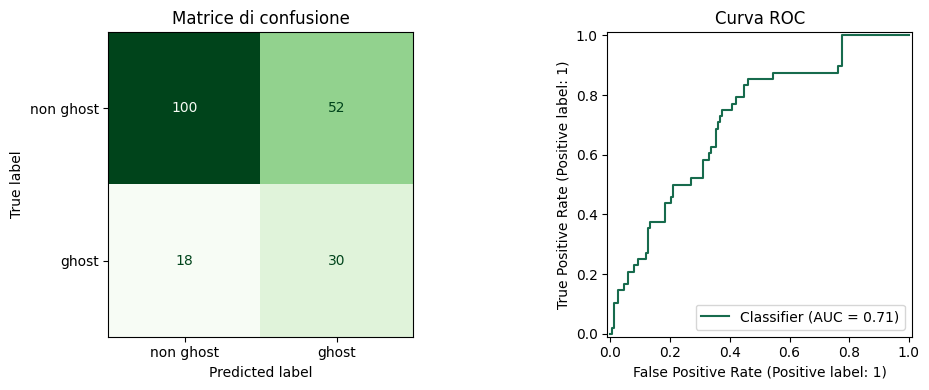

In [3]:
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score,
    classification_report, f1_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical = ["category", "color"]
# Feature engineering dichiarato: sono trasformazioni dei dati di
# catalogazione, non informazioni osservate dopo i 90 giorni.
winter = {"cappotto", "maglione", "giacca"}
summer = {"shorts", "t-shirt"}
df["is_off_season"] = [
    int((cat in winter and month in {4, 5, 6, 7, 8}) or
        (cat in summer and month in {10, 11, 0, 1, 2}))
    for cat, month in zip(df["category"], df["purchase_month"])
]
df["relative_price"] = [
    (price - PRICE_RANGE[cat][0]) / (PRICE_RANGE[cat][1] - PRICE_RANGE[cat][0])
    for cat, price in zip(df["category"], df["price_eur"])
]
numeric = ["purchase_month", "is_off_season", "relative_price"]
X = df[categorical + numeric]
y = df["is_ghost"]

# wear_count e days_owned NON sono feature: il primo rivelerebbe
# l'outcome, il secondo non è noto al momento dell'acquisto.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
model = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", Pipeline([("impute", SimpleImputer()), ("scale", StandardScaler())]), numeric),
    ])),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])
model.fit(X_train, y_train)
probability = model.predict_proba(X_test)[:, 1]
prediction = model.predict(X_test)
print(f"Baseline positiva (prevalenza): {y_test.mean():.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probability):.3f}")
print(f"PR-AUC / average precision: {average_precision_score(y_test, probability):.3f}")
print(f"F1 alla soglia 0.5: {f1_score(y_test, prediction):.3f}")
print(classification_report(y_test, prediction, target_names=["non ghost", "ghost"], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, prediction, display_labels=["non ghost", "ghost"], ax=axes[0], cmap="Greens", colorbar=False)
RocCurveDisplay.from_predictions(y_test, probability, ax=axes[1], color="#176B4D")
axes[0].set_title("Matrice di confusione"); axes[1].set_title("Curva ROC")
plt.tight_layout(); plt.show()

In [4]:
# I coefficienti permettono di spiegare il segno dell'effetto.
cat_names = model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical)
names = list(cat_names) + numeric
coefficients = pd.Series(model.named_steps["model"].coef_[0], index=names).sort_values()
pd.concat([coefficients.head(6), coefficients.tail(6)]).rename("coefficiente").to_frame()

,coefficiente
category_jeans,-0.949436
category_felpa,-0.825324
category_scarpe,-0.631870
category_maglione,-0.469087
category_pantaloni,-0.166950
color_rosso,-0.164542
is_off_season,0.442627
category_cappotto,0.478650
category_gonna,0.512628
color_marrone,0.535211


### Cosa dire all'esame

- È una baseline interpretabile, non una rete neurale.
- ROC-AUC misura l'ordinamento del rischio, non la qualità di una
  singola soglia; precision e recall restano necessarie.
- Le metriche su dati sintetici non dimostrano efficacia reale.
- Prima di usare questa previsione per influenzare acquisti servono
  wear log longitudinali, consenso e controllo di bias/stagionalità.